# Electrostatic Green's Function from a 2D Poisson Solve

This notebook solves a discrete electrostatic Poisson problem on the unit square. A positive point charge and a negative point charge define the source, and the potential satisfies

$$-\Delta \phi = \rho.$$

The inverse Laplacian is the discrete Green's function. We compare a direct solve with the package's inverse-like polynomial transform.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_inverse_polynomial
from qsvt.pde import dirichlet_laplacian_2d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
nx = 10
ny = 10
x, y, L = dirichlet_laplacian_2d(nx, ny)

charge = np.zeros((nx, ny))
pos = (nx // 3, ny // 3)
neg = (2 * nx // 3, 2 * ny // 3)
charge[pos] = 1.0
charge[neg] = -1.0
charge_vec = charge.reshape(-1)

potential_direct_vec = np.linalg.solve(L, charge_vec)
potential_direct = potential_direct_vec.reshape(nx, ny)

potential_direct[pos], potential_direct[neg], np.sum(charge_vec)

(np.float64(0.0037023041787180174),
 np.float64(-0.0037023041787180165),
 np.float64(0.0))

## Inverse-like Green's function approximation

The same inverse-polynomial workflow used for Poisson systems approximates the action of the discrete Green's function on the charge vector. The point-charge source has substantial high-frequency content, so we sweep a small set of polynomial degrees and keep the best approximation against the direct finite-difference solve.


In [3]:
eigenvalues, _ = eigh_hermitian(L)
lambda_min = eigenvalues[0]
lambda_max = eigenvalues[-1]
gamma = lambda_min / lambda_max
condition_number = lambda_max / lambda_min
A = L / lambda_max

candidate_degrees = [9, 13, 17, 21, 25, 29, 33]
candidate_results = []
for degree in candidate_degrees:
    coeffs = design_inverse_polynomial(gamma=gamma, degree=degree)
    candidate_vec = apply_polynomial_to_hermitian(A, coeffs) @ charge_vec
    candidate_vec = candidate_vec / (gamma * lambda_max)
    candidate_error = np.linalg.norm(
        candidate_vec - potential_direct_vec
    ) / np.linalg.norm(potential_direct_vec)
    candidate_results.append((candidate_error, degree, coeffs, candidate_vec))

relative_error, selected_degree, coeffs, potential_poly_vec = min(
    candidate_results,
    key=lambda item: item[0],
)
potential_poly = potential_poly_vec.reshape(nx, ny)

relative_error, selected_degree, condition_number

(np.float64(0.2679780308568579), 29, np.float64(48.37415007870855))

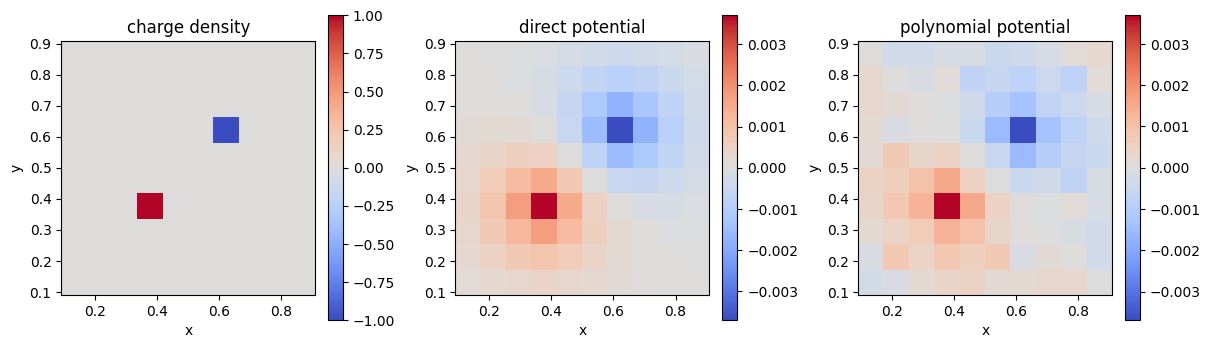

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, field, title, cmap in zip(
    axes,
    [charge, potential_direct, potential_poly],
    ["charge density", "direct potential", "polynomial potential"],
    ["coolwarm", "coolwarm", "coolwarm"],
):
    scale = np.max(np.abs(field))
    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[x[0], x[-1], y[0], y[-1]],
        cmap=cmap,
        vmin=-scale,
        vmax=scale,
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(image, ax=ax, shrink=0.82)

plt.show()

## Validation

Compact checks for charge neutrality, potential signs, and inverse approximation quality.


In [5]:
assert abs(np.sum(charge_vec)) < 1e-12
assert potential_direct[pos] > 0.0
assert potential_direct[neg] < 0.0
assert np.isfinite(relative_error)
assert relative_error < 0.35

print(f"condition_number: {condition_number:.3f}")
print(f"positive_charge_potential: {potential_direct[pos]:.4e}")
print(f"negative_charge_potential: {potential_direct[neg]:.4e}")
print(f"selected_degree: {selected_degree}")
print(f"relative_error: {relative_error:.3e}")
print("validation: passed")

condition_number: 48.374
positive_charge_potential: 3.7023e-03
negative_charge_potential: -3.7023e-03
selected_degree: 29
relative_error: 2.680e-01
validation: passed
